In [2]:
import phidl
import phidl.geometry as pg
from phidl import quickplot as qp
import numpy as np
import os
from phidl import Device, Path
import phidl.path as pp
from scipy.constants import epsilon_0, mu_0
from scipy.special import ellipk
import phidl.routing as pr

In [3]:
def make_cap(center_bus_height=4,num_fingers=5,finger_width=10,finger_height=250,ground_gap=2,pitch=10):

    """
    Rewrite this with symmetric fingers to make port definitions easier.
    """
    cap = phidl.Device('cap')
    # bus_seg = pg.straight((center_bus_height,finger_width+2*ground_gap))
    bus_seg = pg.straight((center_bus_height,1))
    finger_seg = pg.straight((2*finger_height,finger_width))
    # Start with a bus_seg.
    bus_seg_ref = cap.add_ref(bus_seg)
    cap.add_port(bus_seg_ref.ports[1])
    current_port = bus_seg_ref.ports[2]
    for n in range(num_fingers):
        seg_ref = cap.add_ref(finger_seg)
        seg_ref.connect(1,current_port)
        current_port = seg_ref.ports[2]
        seg_ref = cap.add_ref(bus_seg)
        seg_ref.connect(1,current_port)
        current_port = seg_ref.ports[2]
    cap.add_port(current_port)
    cap_outline = pg.outline(cap,distance=ground_gap,open_ports=True)

    return cap_outline

def make_cap_v2(width=100,height=100,ground_gap=2):

    """
    Rewrite this with symmetric fingers to make port definitions easier.
    """
    cap = phidl.Device('cap')
    # bus_seg = pg.straight((center_bus_height,finger_width+2*ground_gap))
    bus_seg = pg.straight((width,height))
    bus_seg_ref = cap.add_ref(bus_seg)
    cap.add_port(bus_seg_ref.ports[1])
    cap.add_port(bus_seg_ref.ports[2])
    cap_outline = pg.outline(cap,distance=ground_gap,open_ports=1000)

    return cap_outline

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


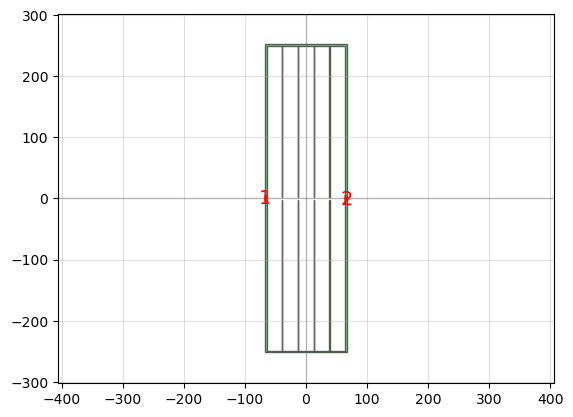

In [4]:
num_fingers = 5
center_height = 4
f_width = 25
f_len = 250
ground_gap=2
cap = make_cap(center_height, num_fingers,f_width, f_len,ground_gap)
cap.rotate(90)
cap.x=0
cap.y=0
qp(cap)

In [5]:
def make_nanowire(
    L_lead=25,
    L_len=50,
    L_width=25,
    radius=5,
    total_length = 1e3,
    width=2,
    ground_plane_gap = 150
):
    P = Path()
    P.append(pp.straight(L_lead))
    direction = -1
    P.append(pp.arc(radius=radius, angle=90 * direction))
    length = 0
    total_len = 0
    while total_len < total_length:

        P.append(pp.straight(L_len))
        length += L_len
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_width))
        length += L_width
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_len))
        length += L_len
        direction *= -1
        total_len = P.length()
        
    P.append(pp.straight(L_len))
    length += L_len
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_width))
    length += L_width
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_len))

    direction *= -1
    
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_lead))
    nanowire = Device('nanowire')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))
    nanowire << P.extrude(X)

    # Now define large ground plane so capacitance is reduced.
    bb = nanowire.get_bounding_box()
    width=bb[1][0]-bb[0][0]
    gp_nanowire = pg.rectangle(size=(width,2*ground_plane_gap))
    gp_nanowire.y = 0
    nanowire_outline = pg.kl_boolean(gp_nanowire,nanowire,operation='A-B')
    nanowire_outline.add_port(1,midpoint=(bb[0][0],0),orientation=-180)
    nanowire_outline.add_port(2,midpoint=(bb[1][0],0),orientation=0)

    return nanowire_outline

In [6]:
def make_dual_stage_filter(nanowire,cap):
    filter = phidl.Device('filter')
    nanowire_ref1 = filter.add_ref(nanowire)
    cap_ref1 = filter.add_ref(cap)
    cap_ref1.connect(1,destination=nanowire_ref1.ports[2])
    nanowire_ref2 = filter.add_ref(nanowire)
    nanowire_ref2.connect(1,destination=cap_ref1.ports[2])
    cap_ref2 = filter.add_ref(cap)
    cap_ref2.connect(1,destination=nanowire_ref2.ports[2])
    nanowire_ref3 = filter.add_ref(nanowire)
    nanowire_ref3.connect(1,destination=cap_ref2.ports[2])
    filter.add_port(nanowire_ref1.ports[1])
    filter.add_port(nanowire_ref3.ports[2])
    return filter

def make_single_stage_filter(nanowire,cap):
    filter = phidl.Device('filter')
    nanowire_ref1 = filter.add_ref(nanowire)
    cap_ref1 = filter.add_ref(cap)

    # Connect them together.
    cap_ref1.connect(1,destination=nanowire_ref1.ports[2])

    # Add ports.
    filter.add_port(nanowire_ref1.ports[1])
    filter.add_port(cap_ref1.ports[2])
    return filter

def make_dual_stage_filter_v2(nanowire,cap):
    filter = phidl.Device('filter')
    nanowire_ref1 = filter.add_ref(nanowire)
    cap_ref1 = filter.add_ref(cap)
    nanowire_ref2 = filter.add_ref(nanowire)
    # cap_ref2 = filter.add_ref(cap)
    # nanowire_ref3 = filter.add_ref(nanowire)

    # Connect them together.
    cap_ref1.connect(1,destination=nanowire_ref1.ports[2])
    nanowire_ref2.connect(1,destination=cap_ref1.ports[2])
    # cap_ref2.connect(1,destination=nanowire_ref2.ports[2])
    # nanowire_ref3.connect(1,destination=cap_ref2.ports[2])

    # Add ports.
    filter.add_port(nanowire_ref1.ports[1])
    # filter.add_port(nanowire_ref2.ports[2])
    filter.add_port(nanowire_ref2.ports[2])
    # filter.add_port(cap_ref2.ports[2])

    return filter

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


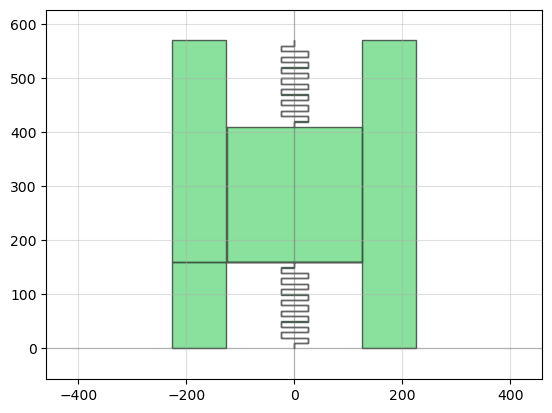

'05092026_lc_filter_20.gds'

In [7]:
height = 250
width = 250
ground_gap=1
cap = make_cap_v2(height,width,ground_gap)
nanowire= make_nanowire(
    L_lead=10,
    L_len = 25,
    L_width = 10,
    radius=0,
    total_length = 750,
    width=0.5,
    ground_plane_gap=125+ground_gap
)
filter = make_dual_stage_filter_v2(nanowire,cap)
filter.rotate(90)
# filter.write_gds('dual_stage_filter.gds')
# qp(filter)

bb = filter.get_bounding_box()
cutout_coords = [(bb[0][0]-100,bb[0][1]),(bb[1][0]+100,bb[1][1])]
filter_cutout = pg.bbox(cutout_coords)
filter_cutout = pg.boolean(filter_cutout,filter,operation='not')
qp(filter_cutout)
filter_cutout.write_gds('05092026_lc_filter_20.gds')

In [8]:
def make_nanowire(
    L_lead=25,
    L_len=50,
    L_width=25,
    radius=5,
    total_length = 1e3,
    width=2,
    ground_plane_gap = 150
):
    P = Path()
    P.append(pp.straight(L_lead))
    direction = -1
    P.append(pp.arc(radius=radius, angle=90 * direction))
    length = 0
    total_len = 0
    while total_len < total_length:

        P.append(pp.straight(L_len))
        length += L_len
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_width))
        length += L_width
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_len))
        length += L_len
        direction *= -1
        total_len = P.length()
        
    P.append(pp.straight(L_len))
    length += L_len
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_width))
    length += L_width
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_len))

    direction *= -1
    
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_lead))
    nanowire = Device('nanowire')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))
    nanowire << P.extrude(X)

    # Now define large ground plane so capacitance is reduced.
    bb = nanowire.get_bounding_box()
    width=bb[1][0]-bb[0][0]
    height = bb[1][1]-bb[0][1]
    gp_nanowire = pg.rectangle(size=(width,2*ground_plane_gap+height))
    gp_nanowire.y = 0
    nanowire_outline = pg.boolean(gp_nanowire,nanowire,operation='A-B')
    nanowire_outline.add_port(1,midpoint=(bb[0][0],0),orientation=-180)
    nanowire_outline.add_port(2,midpoint=(bb[1][0],0),orientation=0)

    return nanowire_outline

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


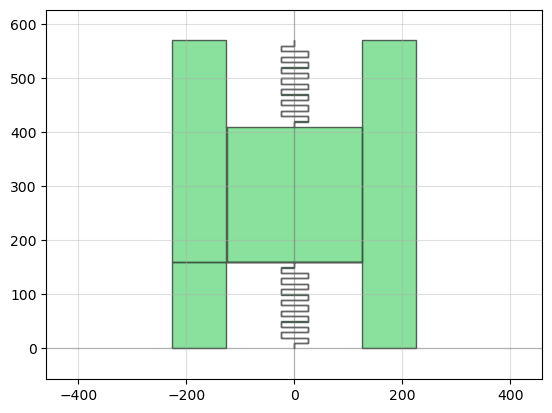

'lclcl_draft_1_1umnw_600um_200um_finger.gds'

In [9]:
bb = filter.get_bounding_box()
cutout_coords = [(bb[0][0]-100,bb[0][1]),(bb[1][0]+100,bb[1][1])]
filter_cutout = pg.bbox(cutout_coords)
filter_cutout = pg.boolean(filter_cutout,filter,operation='not')
qp(filter_cutout)
filter_cutout.write_gds('lclcl_draft_1_1umnw_600um_200um_finger.gds')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


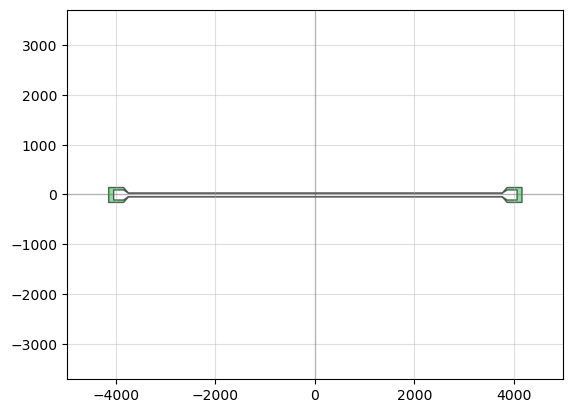

In [10]:
def make_feedline(
        pad_size = 200,
        taper_len = 100,
        feedline_len = 6000,
        feedline_width = 66,
        ground_gap = 2
):
    """
    Need to define a small function internal function make_feedline_sub and call it twice.
    """

    def make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width):
        pad = pg.taper(length=pad_size,width1=pad_size,width2=pad_size)
        taper = pg.taper(length=taper_len,width1=pad_size,width2=feedline_width)
        feedline = pg.taper(length=feedline_len,width1=feedline_width,width2=feedline_width)

        feedline_dev = phidl.Device("feedline")
        pad_ref1 = feedline_dev.add_ref(pad)
        taper_ref1 = feedline_dev.add_ref(taper)
        feedline_ref = feedline_dev.add_ref(feedline)
        taper_ref1.connect(1,destination=pad_ref1.ports[2])
        feedline_ref.connect(1,destination=taper_ref1.ports[2])
        taper_ref2 = feedline_dev.add_ref(taper)
        taper_ref2.connect(2,destination=feedline_ref.ports[2])
        pad_ref2 = feedline_dev.add_ref(pad)
        pad_ref2.connect(1,destination=taper_ref2.ports[1])
        feedline_dev.x=0
        return feedline_dev
    
    feedline1 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)
    pad_size += 100
    feedline_width += 2*ground_gap
    feedline2 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)

    feedline_outline = pg.boolean(feedline2,feedline1,operation='A-B')
    feedline_outline.x = 0
    return feedline_outline

feedline = make_feedline(feedline_len=7500)
qp(feedline)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


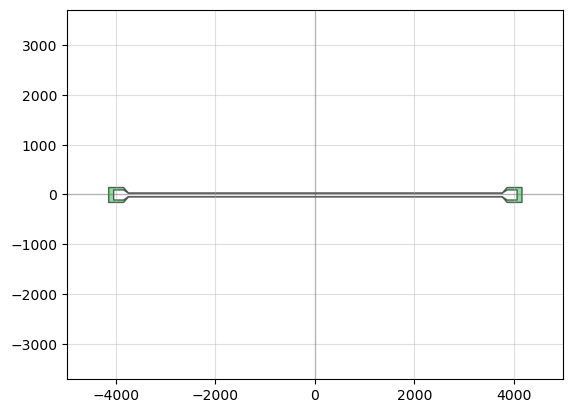

In [11]:
feedline = make_feedline(feedline_len=7500)
qp(feedline)

In [12]:
def make_meander(
    L_lead=100,
    L_len=100,
    radius=50,
    width=2,
    spec_length=4000,
    gap = 30
):
    """
    Makes a meandered path of specified length.
    """
    P = Path()
    P.append(pp.straight(L_lead))
    direction = -1
    P.append(pp.euler(radius=radius, angle=90 * direction, use_eff=True))
    total_length = P.length()
    while total_length < spec_length - (2*L_len+L_lead+3*radius):
        
        P.append(pp.straight(L_len))
        P.append(pp.euler(radius=radius, angle=-180 * direction))
        P.append(pp.straight(L_len))
        direction *= -1
        total_length = P.length()

        if total_length < spec_length - (2*L_len+L_lead+3*radius):
            P.append(pp.straight(radius/4))

    P.append(pp.euler(radius=radius, angle=-90 * direction,use_eff=True))
    P.append(pp.straight(L_lead))
    total_length = P.length()
    print(total_length)
    D = Device('meander')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))
    D << P.extrude(X)
    D.add_port(D.references[0].ports[1])
    D.add_port(D.references[0].ports[2])
    res_outline = pg.outline(D,distance=gap,open_ports=100)
    return res_outline, P.length()

def make_coupled_res(meander,total_gap,coupling_gap,coupling_width,coupling_length,sample_gap,sample_width,sample_length):

    """
    Accepts an extruded path and adds coupling capacitors to the ends.
    """

    coupled_res = Device("meander_res")
    res_ref = coupled_res.add_ref(meander)

    # Now add a coupling capacitor for the feedline.
    # We want a rectangle connected to the end of the line, and a second rectangle of the same width as the outline (2*gap+center_pin_width) and the same length,
    # but 2um longer, to create the outline of the coupling pad.

    def add_coupling_cap(res,port,cap_len,cap_width,cap_gap):

        coupling_cap_outline = pg.taper(length=cap_len,width1=cap_width,width2=cap_width)
        coupling_cap_outline_ref1 = res.add_ref(coupling_cap_outline)
        coupling_cap_outline_ref1.connect(2,port)

        # Now define a cap for the end.
        coupling_cap_len=cap_len+cap_gap
        coupling_cap_outline = pg.taper(length=coupling_cap_len,width1=total_gap,width2=total_gap)
        coupling_cap_outline_ref2 = res.add_ref(coupling_cap_outline)
        coupling_cap_outline_ref2.connect(2,port)
        res = pg.boolean(res,coupling_cap_outline_ref1,operation='A-B')
        return res

    coupled_res = add_coupling_cap(coupled_res,res_ref.ports[1],coupling_length,coupling_width,coupling_gap)
    coupled_res = add_coupling_cap(coupled_res,res_ref.ports[2],sample_length,sample_width,sample_gap)

    # Now add ports for connecting to both gate lines and feedlines.
    bb = coupled_res.get_bounding_box()
    x0 = bb[0][0]
    x1 = bb[1][0] - sample_gap
    coupled_res.add_port(
        name='feedline_port',
        midpoint=(x0,0),
        width=1,
        orientation=180
    )

    coupled_res.add_port(
        name='gateline_port',
        midpoint=(x1,-total_gap/3),
        width=1,
        orientation=0
    )

    coupled_res.add_port(
        name='gateline_port2',
        midpoint=(x1,total_gap/3),
        width=1,
        orientation=0
    )

    midpoint = res_ref.ports[2].midpoint
    midpoint[0] = midpoint[0] + sample_length
    coupled_res.add_port(
        name='driveline_port',
        midpoint=midpoint,
        width=1,
        orientation=0
    )

    coupled_res.rotate(90)
    return coupled_res

4068.762266868159


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


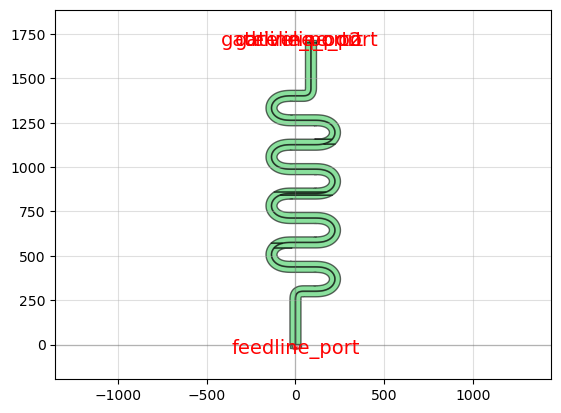

'arb_coupling_caps.gds'

In [13]:
center_pin_width = 2
ground_gap = 30
total_gap = 2*ground_gap+center_pin_width
coupling_gap = 2
coupling_width = 40
coupling_length = 20
sample_gap = 2
sample_width = 20
sample_length=10
meander, length = make_meander(L_len = 50,L_lead = 250,spec_length=4000,radius=50,width=center_pin_width)
res_outline = make_coupled_res(meander,total_gap,coupling_gap,coupling_width,coupling_length,sample_gap,sample_width,sample_length)
qp(res_outline)
res_outline.write_gds('arb_coupling_caps.gds')

In [14]:
def make_coupled_lambda4_res(meander,total_gap,coupling_gap,coupling_width,coupling_length):

    """
    Accepts an extruded path and adds coupling capacitors to the ends.
    """

    coupled_res = Device("meander_res")
    res_ref = coupled_res.add_ref(meander)

    # Now add a coupling capacitor for the feedline.
    # We want a rectangle connected to the end of the line, and a second rectangle of the same width as the outline (2*gap+center_pin_width) and the same length,
    # but 2um longer, to create the outline of the coupling pad.

    def add_coupling_cap(res,port,cap_len,cap_width,cap_gap):

        coupling_cap_outline = pg.taper(length=cap_len,width1=cap_width,width2=cap_width)
        coupling_cap_outline_ref1 = res.add_ref(coupling_cap_outline)
        coupling_cap_outline_ref1.connect(2,port)

        # Now define a cap for the end.
        coupling_cap_len=cap_len+cap_gap
        coupling_cap_outline = pg.taper(length=coupling_cap_len,width1=total_gap,width2=total_gap)
        coupling_cap_outline_ref2 = res.add_ref(coupling_cap_outline)
        coupling_cap_outline_ref2.connect(2,port)
        res = pg.boolean(res,coupling_cap_outline_ref1,operation='A-B')
        return res

    coupled_res = add_coupling_cap(coupled_res,res_ref.ports[1],coupling_length,coupling_width,coupling_gap)

    # Now add ports for connecting to both gate lines and feedlines.
    bb = coupled_res.get_bounding_box()
    x0 = bb[0][0]
    x1 = bb[1][0]
    coupled_res.add_port(
        name='feedline_port',
        midpoint=(x0,0),
        width=1,
        orientation=180
    )

    coupled_res.rotate(90)
    return coupled_res

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


1935.4676107693176


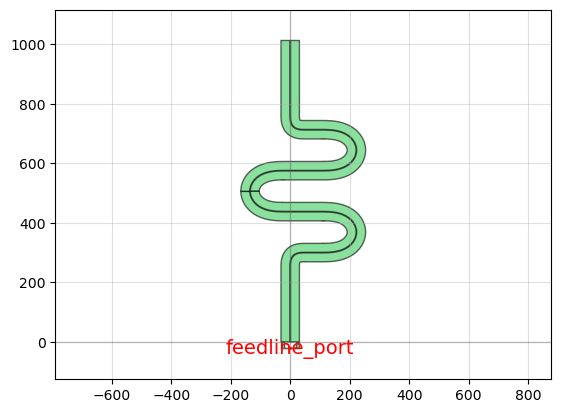

In [15]:
center_pin_width = 2
ground_gap = 30
total_gap = 2*ground_gap+center_pin_width
coupling_gap = 2
coupling_width = 40
coupling_length = 20
meander, length = make_meander(L_len = 50,L_lead = 250,spec_length=2000,radius=50,width=center_pin_width)
lambda4_res_outline = make_coupled_lambda4_res(meander,total_gap,coupling_gap,coupling_width,coupling_length)
qp(lambda4_res_outline)

In [16]:
def make_filter_contact(
        pad_size = 200,
        taper_len = 100,
        feedline_len = 0,
        feedline_width = 66,
        ground_gap = 2,
        second_taper = 250,
        taper_to = 5,
        stub_len = 50
):

    def make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width):
        pad = pg.taper(length=pad_size,width1=pad_size,width2=pad_size)
        taper = pg.taper(length=taper_len,width1=pad_size,width2=feedline_width)
        feedline = pg.taper(length=feedline_len,width1=feedline_width,width2=feedline_width)

        feedline_dev = phidl.Device("feedline")
        pad_ref1 = feedline_dev.add_ref(pad)
        taper_ref1 = feedline_dev.add_ref(taper)
        feedline_ref = feedline_dev.add_ref(feedline)
        taper_ref1.connect(1,destination=pad_ref1.ports[2])
        feedline_ref.connect(1,destination=taper_ref1.ports[2])
        feedline_dev.xmax = 0
        return feedline_dev
    
    feedline1 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)
    pad_size += 100
    feedline_width += 2*ground_gap
    feedline2 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)

    feedline_outline = pg.boolean(feedline2,feedline1,operation='A-B')
    feedline_outline.xmax = 0
    feedline_outline.add_port(
        'feedline',
        midpoint = (0,0),
        width = 1,
        orientation=0
    )
    feedline_outline.x = 0

    feedline_width -= 2*ground_gap
    # Now just taper a line down to 1um with 2um gap.
    taper = pg.taper(second_taper,feedline_width,taper_to)
    taper_outline = pg.outline(taper,ground_gap,open_ports=100)

    rect = pg.rectangle((second_taper,feedline_width+2*ground_gap))
    rect.y=0
    cut_taper_outline = pg.boolean(taper_outline,rect,operation='and')
    cut_taper_outline.add_port(taper_outline.ports[1])
    cut_taper_outline.add_port(taper_outline.ports[2])
    taper_outline = cut_taper_outline

    stub = pg.straight((taper_to,stub_len))
    stub_outline = pg.outline(stub,ground_gap,open_ports=100)
    
    contact_dev = phidl.Device('contact')
    contact_ref = contact_dev.add_ref(feedline_outline)
    taper_ref = contact_dev.add_ref(taper_outline)
    taper_ref.connect(1,contact_ref.ports['feedline'])
    stub_ref = contact_dev.add_ref(stub_outline)
    stub_ref.connect(1,taper_ref.ports[2])

    contact_dev.add_port(stub_ref.ports[2])

    return contact_dev

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


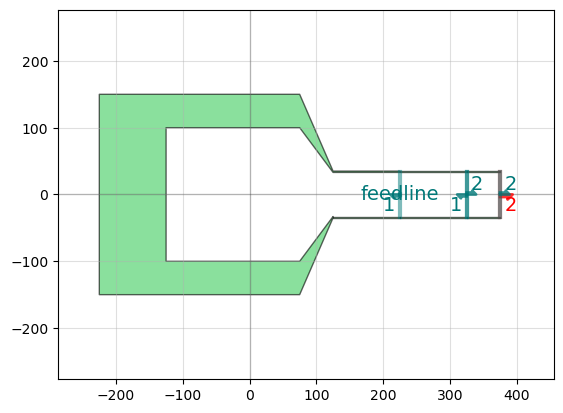

{2: Port (name 2, midpoint [375.   0.], width 66, orientation 0)}

In [17]:
contact = make_filter_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 100,
    feedline_width = 66,
    ground_gap = 2,
    second_taper = 100,
    taper_to = 66,
    stub_len = 50
)
# Just have it taper, then place the pads and connect with connecting ports.
qp(contact)
contact.ports

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


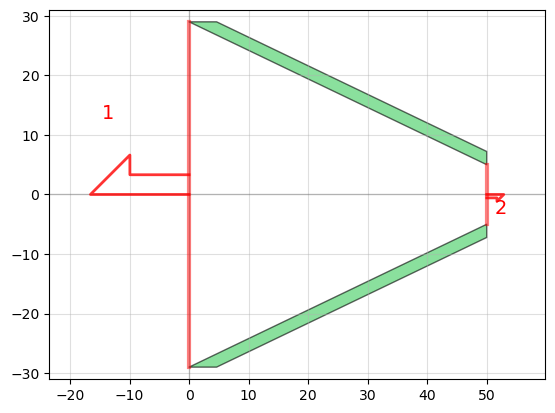

In [18]:
width1 = 66-2*4
taper = pg.taper(50,66-2*4,10)
taper_outline = pg.outline(taper,2,open_ports=100)
rect = pg.rectangle((50,width1))
rect.y=0
cut_taper_outline = pg.boolean(taper_outline,rect,operation='and')
cut_taper_outline.add_port(taper_outline.ports[1])
cut_taper_outline.add_port(taper_outline.ports[2])
qp(cut_taper_outline)

In [19]:
center_pin_width = 2
ground_gap = 60
total_gap = 2*ground_gap+center_pin_width
coupling_gap = 2
coupling_width = 80
coupling_length = 20
sample_gap = 2
sample_width = 20
sample_length=10

# Sample resonator.
# Make meandered path.
sample_meander, length = make_meander(L_len = 50,L_lead = 250,spec_length=3750,radius=75,width=center_pin_width,gap=ground_gap)
# Then add coupling pads.
sample_res = make_coupled_res(sample_meander,total_gap,coupling_gap,coupling_width,coupling_length,sample_gap,sample_width,sample_length)

# Reference lamda/2!
# Make meandered path.
lamda2_meander, length = make_meander(L_len = 50,L_lead = 250,spec_length=3000,radius=75,width=center_pin_width,gap=ground_gap)
# Then add coupling pads.
lamda2_res = make_coupled_res(lamda2_meander,total_gap,coupling_gap,coupling_width,coupling_length,sample_gap,sample_width,sample_length)

# Reference lamda/4!
lamda4_meander, length = make_meander(L_len = 50,L_lead = 250,spec_length=1250,radius=75,width=center_pin_width,gap=ground_gap)
# Then add coupling pads.
lamda4_res = make_coupled_lambda4_res(lamda4_meander,total_gap,coupling_gap,coupling_width,coupling_length)

3683.1782098132812
3093.189812983629
1323.2246224946718


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


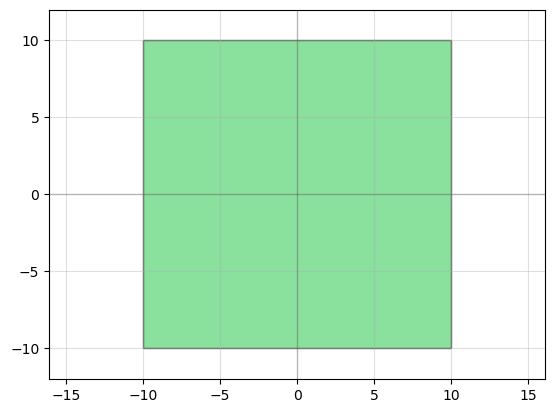

In [20]:
marker = pg.rectangle(size = (20,20))
marker.x = 0
marker.y=0
qp(marker)

In [21]:
def make_sample_nanowire(
    L_lead=10,
    L_len=50,
    L_width=25,
    radius=5,
    total_length = 1e3,
    width=2,
    cap_width = 10,
    cap_len = 5
):
    P = Path()
    P.append(pp.straight(L_lead))
    direction = -1
    P.append(pp.arc(radius=radius, angle=90 * direction))
    length = 0
    total_len = 0
    while total_len < total_length - 2*(L_len + L_width + L_len):

        P.append(pp.straight(L_len))
        length += L_len
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_width))
        length += L_width
        P.append(pp.arc(radius=radius, angle=-90 * direction))
        P.append(pp.straight(L_len))
        length += L_len
        direction *= -1
        total_len = P.length()
        
    P.append(pp.straight(L_len))
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_width))
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_len-2*radius))

    direction *= -1
    
    P.append(pp.arc(radius=radius, angle=-90 * direction))
    P.append(pp.straight(L_lead))
    actual_len = P.length()

    D = Device('meander')
    X = phidl.CrossSection()
    X.add(width = width, ports = (1,2))
    D << P.extrude(X)
    D.add_port(1,D.references[0].ports[1].midpoint,orientation=180)
    D.add_port(2,D.references[0].ports[2].midpoint,orientation=0)

    print(D.ports)

    lead_len = (total_length-actual_len)/2
    print(lead_len*2+actual_len)
    lead = pg.taper(length=lead_len, width1=width, width2=width)

    res = phidl.Device('res')
    lead1 = res.add_ref(lead)
    lead2 = res.add_ref(lead)
    meander = res.add_ref(D)

    lead1.connect(2,meander.ports[1])
    lead2.connect(1,meander.ports[2])

    # Now get bounding box.
    bb = res.bbox
    sample_gap = bb[1][0] - bb[0][0]
    print(sample_gap)

    cap = pg.taper(length=cap_len, width1=cap_width, width2=cap_width)

    cap1 = res.add_ref(cap)
    cap2 = res.add_ref(cap)

    cap1.connect(2,lead1.ports[1])
    cap2.connect(1,lead2.ports[2])

    res.add_port(lead1.ports[1])

    return res, sample_gap

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


{1: Port (name 1, midpoint [0. 0.], width 1, orientation 180), 2: Port (name 2, midpoint [ 1.60000000e+01 -2.22044605e-16], width 1, orientation 0)}
150.0
18.29208713337089


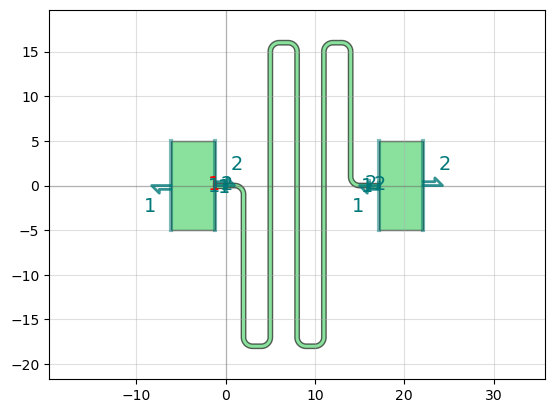

In [22]:
ti_sample, ti_sample_gap = make_sample_nanowire(
    L_lead=1,
    L_len = 16,
    L_width = 1,
    radius=1,
    total_length = 150,
    width=0.5
)
qp(ti_sample)

In [23]:
def make_hb_contact(
        pad_size = 200,
        taper_len = 100,
        feedline_len = 0,
        feedline_width = 25,
        ground_gap = 2,
        second_taper = 250,
        taper_to = 2,
        stub_len = 1
):

    def make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width):
        pad = pg.taper(length=pad_size,width1=pad_size,width2=pad_size)
        taper = pg.taper(length=taper_len,width1=pad_size,width2=feedline_width)
        feedline = pg.taper(length=feedline_len,width1=feedline_width,width2=feedline_width)

        feedline_dev = phidl.Device("feedline")
        pad_ref1 = feedline_dev.add_ref(pad)
        taper_ref1 = feedline_dev.add_ref(taper)
        feedline_ref = feedline_dev.add_ref(feedline)
        taper_ref1.connect(1,destination=pad_ref1.ports[2])
        feedline_ref.connect(1,destination=taper_ref1.ports[2])
        feedline_dev.xmax = 0
        return feedline_dev
    
    feedline1 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)
    pad_size += 100
    feedline_width += 2*ground_gap
    feedline2 = make_feedline_sub(pad_size,taper_len,feedline_len,feedline_width)

    feedline_outline = pg.boolean(feedline2,feedline1,operation='A-B')
    feedline_outline.xmax = 0
    feedline_outline.add_port(
        'feedline',
        midpoint = (0,0),
        width = 1,
        orientation=0
    )
    feedline_outline.x = 0

    return feedline_outline

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


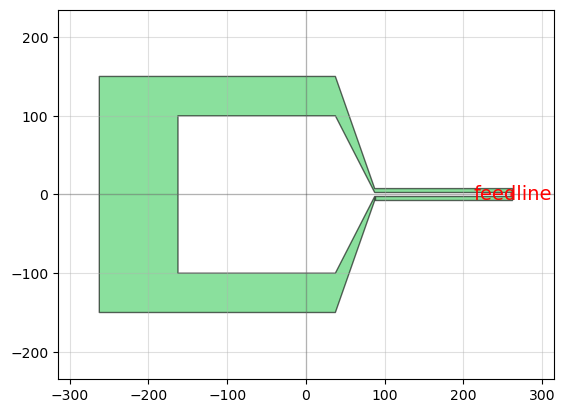

{'feedline': Port (name feedline, midpoint [262.5   0. ], width 1, orientation 0)}


In [24]:
hb_contact = make_hb_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 175,
    feedline_width = 5,
    ground_gap = 5,
    second_taper = 1,
    taper_to = 10,
    stub_len = 50
)
qp(hb_contact)
print(hb_contact.ports)

In [25]:
def make_hallbar():

    hallbar = phidl.Device("hb")
    sample_long = pg.taper(length=50, width1=2, width2=2)
    sample_trans = pg.taper(length=10, width1=2, width2=2)
    samplelong_ref = hallbar.add_ref(sample_long)
    samplelong_ref.x=0

    sampletrans_ref1 = hallbar.add_ref(sample_trans)
    sampletrans_ref1.rotate(90)
    sampletrans_ref1.x = -50/4
    sampletrans_ref1.y = 0

    sampletrans_ref2 = hallbar.add_ref(sample_trans)
    sampletrans_ref2.rotate(90)
    sampletrans_ref2.x = 50/4
    sampletrans_ref2.y = 0

    sample_cutout = pg.taper(length=50, width1=20, width2=20)
    samplecutout_ref = hallbar.add_ref(sample_cutout)
    samplecutout_ref.x=0

    # Now add longitudinal contacts.
    c1 = hallbar.add_ref(hb_contact)
    c2 = hallbar.add_ref(hb_contact)

    c1.connect('feedline',samplelong_ref.ports[1])
    c2.connect('feedline',samplelong_ref.ports[2])

    def connect_filter_to_port(res_port,filter_port,width,gap,init_len):
        connect = phidl.routing.path_U(res_port,filter_port,length1=init_len)
        X = phidl.CrossSection()
        X.add(width = width, ports = ('in','out'))
        connect = connect.extrude(X)
        connect = pg.outline(connect,distance = gap, open_ports=100)
        return connect
    
    c3 = hallbar.add_ref(hb_contact)
    c3.rotate(90)
    c3.x = -175
    c3.ymax = -150
    connect = connect_filter_to_port(c3.ports['feedline'],sampletrans_ref1.ports[1],width=5,gap=5,init_len=100)
    connect_ref = hallbar.add_ref(connect)
    connect_ref.connect('in',c3.ports['feedline'])

    c4 = hallbar.add_ref(hb_contact)
    c4.rotate(90)
    c4.x = 175
    c4.ymax = -150
    connect = connect_filter_to_port(c4.ports['feedline'],sampletrans_ref2.ports[1],width=5,gap=5,init_len=100)
    connect_ref = hallbar.add_ref(connect)
    connect_ref.connect('in',c4.ports['feedline'])

    c5 = hallbar.add_ref(hb_contact)
    c5.rotate(-90)
    c5.x = -175
    c5.ymin = 150
    connect = connect_filter_to_port(c5.ports['feedline'],sampletrans_ref1.ports[2],width=5,gap=5,init_len=100)
    connect_ref = hallbar.add_ref(connect)
    connect_ref.connect('in',c5.ports['feedline'])

    c6 = hallbar.add_ref(hb_contact)
    c6.rotate(-90)
    c6.x = 175
    c6.ymin = 150
    connect = connect_filter_to_port(c6.ports['feedline'],sampletrans_ref2.ports[2],width=5,gap=5,init_len=100)
    connect_ref = hallbar.add_ref(connect)
    connect_ref.connect('in',c6.ports['feedline'])

    return hallbar

def make_hb_sample():
    
    hallbar = phidl.Device("hb")
    sample_long = pg.taper(length=55, width1=0.5, width2=0.5)
    sample_trans = pg.taper(length=25, width1=0.5, width2=0.5)
    samplelong_ref = hallbar.add_ref(sample_long)
    samplelong_ref.x=0

    sampletrans_ref1 = hallbar.add_ref(sample_trans)
    sampletrans_ref1.rotate(90)
    sampletrans_ref1.x = -50/4
    sampletrans_ref1.y = 0

    sampletrans_ref2 = hallbar.add_ref(sample_trans)
    sampletrans_ref2.rotate(90)
    sampletrans_ref2.x = 50/4
    sampletrans_ref2.y = 0

    return hallbar

In [26]:
hb = make_hallbar()
hb.remap_layers({0:100})
hb_sample = make_hb_sample()
hb_sample.remap_layers({0:1000})

hallbar_dev = phidl.Device('HB')
hallbar_dev.add_ref(hb)
hallbar_dev.add_ref(hb_sample)

DeviceReference (parent Device "hb", ports [], origin (0, 0), rotation 0, x_reflection False)

In [27]:
centering = pg.rectangle((10000,10000))
centering .remap_layers({0:10000})
centering.x=0
centering.y=0

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


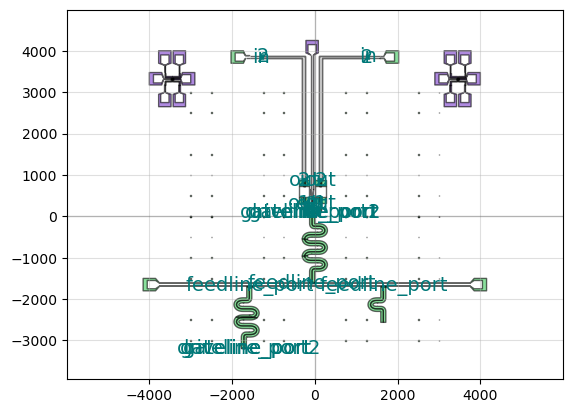

'071226_ti_res_driveline_etched_gp_with_hb.gds'

In [ ]:
layout = phidl.Device('layout')
feedline_ref = layout.add_ref(feedline)
feedline_ref.y = -1650
sample_res_ref = layout.add_ref(sample_res)

# Add a port here and connect to it!!!
sample_res_ref.x = 0

# Place
sample_res_ref.movey(55-1650)
filter_ref1 = layout.add_ref(filter)
filter_ref2 = layout.add_ref(filter)
filter_ref1.x = 200-66
filter_ref1.y = 600
filter_ref2.x = -200-66
filter_ref2.y = 600

def connect_filter_to_port(res_port,filter_port,width,gap,init_len):
    connect = phidl.routing.path_U(res_port,filter_port,length1=init_len)
    X = phidl.CrossSection()
    X.add(width = width, ports = ('in','out'))
    connect = connect.extrude(X)
    connect = pg.outline(connect,distance = gap, open_ports=100)
    return connect

connect = connect_filter_to_port(sample_res_ref.ports['gateline_port'],filter_ref1.ports[1],width=5,gap=1,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',sample_res_ref.ports['gateline_port'])

connect = connect_filter_to_port(sample_res_ref.ports['gateline_port2'],filter_ref2.ports[1],width=5,gap=1,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',sample_res_ref.ports['gateline_port2'])

contact = make_filter_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 100,
    feedline_width = 66,
    ground_gap = 2,
    second_taper = 300,
    taper_to = 66,
    stub_len = 1
)

def connect_filter_to_bondpad(res_port,filter_port,width,gap,init_len):
    connect = phidl.routing.path_L(res_port,filter_port)
    X = phidl.CrossSection()
    X.add(width = width, ports = ('in','out'))
    connect = connect.extrude(X)
    connect = pg.outline(connect,distance = gap, open_ports=100)
    return connect

contact_ref1 = layout.add_ref(contact)
contact_ref1.rotate(-180)
contact_ref1.x = 1650
contact_ref1.ymax = 4000
connect = connect_filter_to_bondpad(contact_ref1.ports[2],filter_ref1.ports[2],width=66,gap=2,init_len=2000)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',contact_ref1.ports[2])

contact_ref2 = layout.add_ref(contact)
contact_ref2.x = -1650
contact_ref2.ymax = 4000
connect = connect_filter_to_bondpad(contact_ref2.ports[2],filter_ref2.ports[2],width=66,gap=2,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',contact_ref2.ports[2])

# Add reference resonators.
ref_res1 = layout.add_ref(lamda2_res)
ref_res1.rotate(180)
ref_res1.x = -1650
ref_res1.movey(-55-1650)

# Now add driveline.
driveline_x_coord = sample_res_ref.ports['driveline_port'].center[0] 
driveline_y_coord = sample_res_ref.ports['driveline_port'].center[1] + 50

len = 10
width=10
stub = pg.rectangle((len,width))
stub.add_port(1,midpoint=(len,width/2),orientation=0)
stub.rotate(90)
stub_outline = pg.outline(stub,2,open_ports=100)
stub_outline.remap_layers(layermap={0:100})
stub_ref = layout.add_ref(stub_outline)
stub_ref.ymin=driveline_y_coord
stub_ref.x=driveline_x_coord

driveline = make_filter_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 3250,
    feedline_width = 66,
    ground_gap = 2,
    second_taper = 300,
    taper_to = 10,
    stub_len = 50
)

driveline.remap_layers(layermap={0:100})
driveline_ref = layout.add_ref(driveline)
driveline_ref.rotate(-90)
driveline_ref.ymax = 4250
driveline_ref.x = driveline_x_coord

connect = connect_filter_to_port(stub_ref.ports[1],driveline_ref.ports[2],width=10,gap=2,init_len=10)
connect.remap_layers(layermap={0:100})
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',stub_ref.ports[1])

# Now etch out ground plane!!!
len = ti_sample_gap-sample_gap+1
width=122
stub = pg.rectangle((width,len))
stub.remap_layers({0:100})
stub_ref = layout.add_ref(stub)
stub_ref.ymin=sample_res_ref.ports['driveline_port'].center[1] + sample_gap -1
stub_ref.x=driveline_x_coord

ti_sample = ti_sample.remap_layers({0:1000})
ti_ref = layout.add_ref(ti_sample)
ti_ref.connect(1,sample_res_ref.ports['driveline_port'])

ref_res2 = layout.add_ref(lamda4_res)
ref_res2.rotate(180)
ref_res2.x = 1500
ref_res2.movey(-55-1650)

# ADD ALIGNMENT MARKERS!!!
marker_locs = [(500,0),(500,-500),(500,-1000),(500,-1500),(500,-2500),(500,-3000)]
for marker_loc in marker_locs:
    for xmag in [-1.5,1.5,-2.5,2.5,-5,5,-6,6]:
        for ymag in [1,-1]:
            xloc = xmag*marker_loc[0]
            yloc = ymag*marker_loc[1]
            marker_ref = layout.add_ref(marker)
            marker_ref.x = xloc
            marker_ref.y = yloc

hb1 = layout.add_ref(hallbar_dev)
hb1.xmin = -4000
hb1.ymax = 4000

hb2 = layout.add_ref(hallbar_dev)
hb2.xmax = 4000
hb2.ymax = 4000

qp(layout)
layout.write_gds("071426_ti_res_driveline_etched_gp_with_hb.gds")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


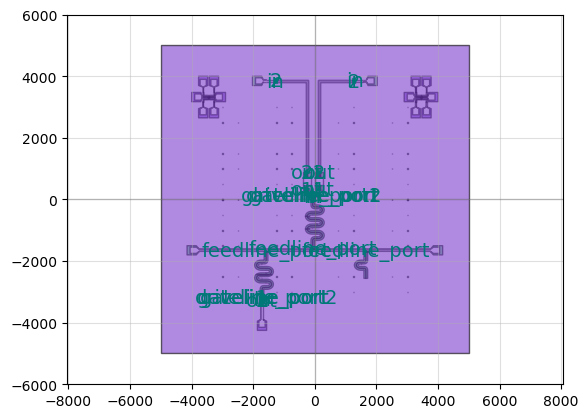

'071626_ti_res_driveline_etched_gp_with_hb.gds'

In [29]:
layout = phidl.Device('layout')
feedline_ref = layout.add_ref(feedline)
feedline_ref.y = -1650
sample_res_ref = layout.add_ref(sample_res)

# Add a port here and connect to it!!!
sample_res_ref.x = 0

# Place
sample_res_ref.movey(55-1650)
filter_ref1 = layout.add_ref(filter)
filter_ref2 = layout.add_ref(filter)
filter_ref1.x = 200-66
filter_ref1.y = 600
filter_ref2.x = -200-66
filter_ref2.y = 600

def connect_filter_to_port(res_port,filter_port,width,gap,init_len):
    connect = phidl.routing.path_U(res_port,filter_port,length1=init_len)
    X = phidl.CrossSection()
    X.add(width = width, ports = ('in','out'))
    connect = connect.extrude(X)
    connect = pg.outline(connect,distance = gap, open_ports=100)
    return connect

connect = connect_filter_to_port(sample_res_ref.ports['gateline_port'],filter_ref1.ports[1],width=5,gap=1,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',sample_res_ref.ports['gateline_port'])

connect = connect_filter_to_port(sample_res_ref.ports['gateline_port2'],filter_ref2.ports[1],width=5,gap=1,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',sample_res_ref.ports['gateline_port2'])

contact = make_filter_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 100,
    feedline_width = 66,
    ground_gap = 2,
    second_taper = 300,
    taper_to = 66,
    stub_len = 1
)

def connect_filter_to_bondpad(res_port,filter_port,width,gap,init_len):
    connect = phidl.routing.path_L(res_port,filter_port)
    X = phidl.CrossSection()
    X.add(width = width, ports = ('in','out'))
    connect = connect.extrude(X)
    connect = pg.outline(connect,distance = gap, open_ports=100)
    return connect

contact_ref1 = layout.add_ref(contact)
contact_ref1.rotate(-180)
contact_ref1.x = 1650
contact_ref1.ymax = 4000
connect = connect_filter_to_bondpad(contact_ref1.ports[2],filter_ref1.ports[2],width=66,gap=2,init_len=2000)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',contact_ref1.ports[2])

contact_ref2 = layout.add_ref(contact)
contact_ref2.x = -1650
contact_ref2.ymax = 4000
connect = connect_filter_to_bondpad(contact_ref2.ports[2],filter_ref2.ports[2],width=66,gap=2,init_len=10)
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',contact_ref2.ports[2])

# Add reference resonators.
ref_res1 = layout.add_ref(lamda2_res)
ref_res1.rotate(180)
ref_res1.x = -1650
ref_res1.movey(-55-1650)

# Now add driveline.
driveline_x_coord = ref_res1.ports['driveline_port'].center[0] 
driveline_y_coord = ref_res1.ports['driveline_port'].center[1] - 50 - sample_length

len = 10
width=10
stub = pg.rectangle((len,width))
stub.add_port(1,midpoint=(len,width/2),orientation=0)
stub.rotate(-90)
stub_outline = pg.outline(stub,4,open_ports=100)
stub_outline.remap_layers(layermap={0:100})
stub_ref = layout.add_ref(stub_outline)
stub_ref.ymin=driveline_y_coord
stub_ref.x=driveline_x_coord

driveline = make_filter_contact(
    pad_size = 200,
    taper_len = 50,
    feedline_len = 500,
    feedline_width = 80,
    ground_gap = 4,
    second_taper = 100,
    taper_to = 10,
    stub_len = 10
)

driveline.remap_layers(layermap={0:100})
driveline_ref = layout.add_ref(driveline)
driveline_ref.rotate(90)
driveline_ref.ymin = -4250
driveline_ref.x = driveline_x_coord

connect = connect_filter_to_port(stub_ref.ports[1],driveline_ref.ports[2],width=10,gap=4,init_len=10)
connect.remap_layers(layermap={0:100})
connect_ref = layout.add_ref(connect)
connect_ref.connect('in',stub_ref.ports[1])

# # Now etch out ground plane!!!
len = ti_sample_gap-sample_gap+1
width=122
stub = pg.rectangle((width,len))
stub.remap_layers({0:100})
stub_ref = layout.add_ref(stub)
stub_ref.ymax=ref_res1.ports['driveline_port'].center[1] - sample_gap + 1
stub_ref.x=driveline_x_coord

ti_sample = ti_sample.remap_layers({0:1000})
ti_ref = layout.add_ref(ti_sample)
ti_ref.connect(1,ref_res1.ports['driveline_port'])

ref_res2 = layout.add_ref(lamda4_res)
ref_res2.rotate(180)
ref_res2.x = 1500
ref_res2.movey(-55-1650)

# # ADD ALIGNMENT MARKERS!!!
marker_locs = [(500,0),(500,-500),(500,-1000),(500,-1500),(500,-2500),(500,-3000)]
for marker_loc in marker_locs:
    for xmag in [-1.5,1.5,-2.5,2.5,-5,5,-6,6]:
        for ymag in [1,-1]:
            xloc = xmag*marker_loc[0]
            yloc = ymag*marker_loc[1]
            marker_ref = layout.add_ref(marker)
            marker_ref.x = xloc
            marker_ref.y = yloc

hb1 = layout.add_ref(hallbar_dev)
hb1.xmin = -4000
hb1.ymax = 4000

hb2 = layout.add_ref(hallbar_dev)
hb2.xmax = 4000
hb2.ymax = 4000

layout.add_ref(centering)

qp(layout)
layout.write_gds("071626_ti_res_driveline_etched_gp_with_hb.gds")

In [58]:
layout.write_gds("070926_ti_res_driveline_etched_gp.gds")

'070926_ti_res_driveline_etched_gp.gds'